In [2]:
import pandas as pd
import seaborn as sns

#Load Dataset
df = sns.load_dataset("titanic")

#Saving the Dataset
df.to_csv("tiatanic.csv", index=False)

#Dataset Profile
print(f"Dataset Information:")
df.info()

print(f"Descriptive Statistics")
print(df.describe())

print(f"Dataset shape:")
print(df.shape)

#Percentage of missing values in every column
missing_percentage = (df.isnull().mean()*100)
missing_percentage = missing_percentage[missing_percentage > 0]

print("\n Prescentage of Missing values: \n", missing_percentage)

#Apply threshold rule
# Under 5% missing: Drop rows

df = df.dropna(subset=["embarked","embark_town"])

# 5%–30% missing: Impute
# column age has 19% of null values, so taking the median of age 
df['age']=df['age'].fillna(df['age'].median())

# Above 30% missing: Explicitly decide whether to drop or encode
#deck has 77% of missing values high imputation would be unreliable so dropping the column

df = df.drop(columns=['deck'])

#Verify

print("\nMissing values after handling:")
print(df.isnull().sum())

print("\n Dataset shape after handling:")
print(df.shape)


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
Descriptive Statistics
         survived      pclass         age       si

C:\Users\krish\AppData\Local\Temp\ipykernel_14740\3676654264.py:15: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(df[column], vert=False)


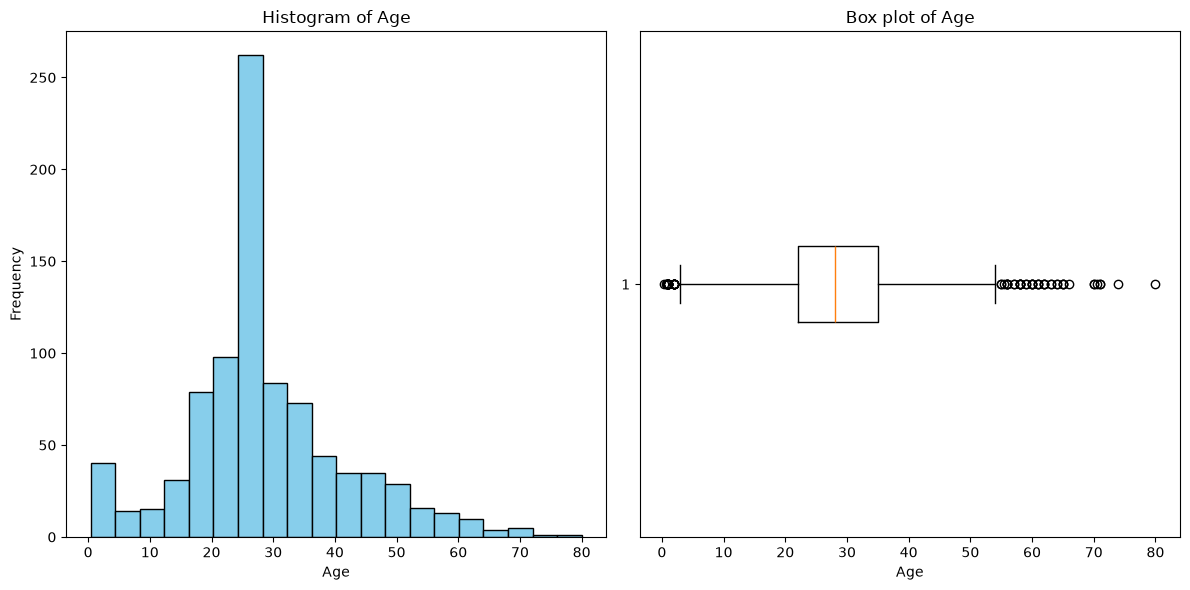

C:\Users\krish\AppData\Local\Temp\ipykernel_14740\3676654264.py:15: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(df[column], vert=False)


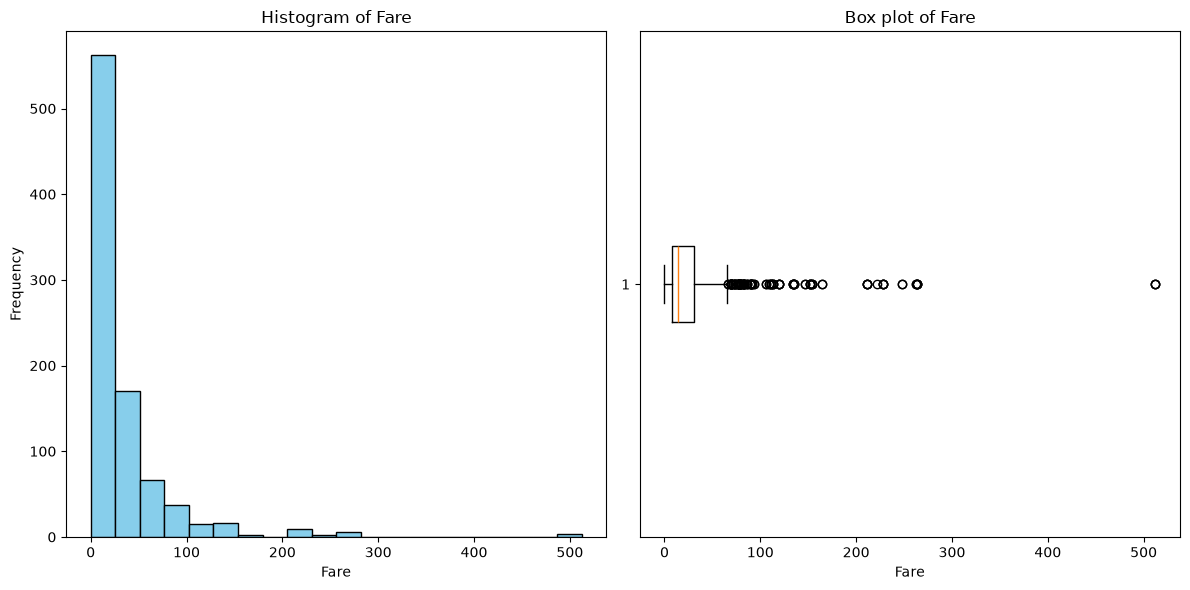


Column: age
Q1: 22.0000
Q3: 35.0000
IQR: 13.0000
Lower Bound: 2.5000
Upper Bound: 54.5000
Number of Outliers: 65

Column: fare
Q1: 7.8958
Q3: 31.0000
IQR: 23.1042
Lower Bound: -26.7605
Upper Bound: 65.6563
Number of Outliers: 114

Fare Statistics
Mean: 32.0967
Median: 14.4542
Mode: [8.05]

Written Distribution:
The fare distribution is right-skewed because the mean is greater than the median. The mode is also lower than the median, supporting the presence of higher-fare values that pull the mean upward.


In [3]:
# Histogram and Box plot using Seaborn
import matplotlib.pyplot as plt

for column in ['age', 'fare']:

    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    # Histogram
    ax[0].hist(df[column], bins=20, color='skyblue', edgecolor='black')
    ax[0].set_title(f"Histogram of {column.capitalize()}")
    ax[0].set_xlabel(column.capitalize())
    ax[0].set_ylabel("Frequency")

    # Boxplot
    ax[1].boxplot(df[column], vert=False)
    ax[1].set_title(f"Box plot of {column.capitalize()}")
    ax[1].set_xlabel(column.capitalize())

    plt.tight_layout()
    plt.show()


# IQR outlier calculation
for column in ['age', 'fare']:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(f"\nColumn: {column}")
    print(f"Q1: {Q1:.4f}")
    print(f"Q3: {Q3:.4f}")
    print(f"IQR: {IQR:.4f}")
    print(f"Lower Bound: {lower_bound:.4f}")
    print(f"Upper Bound: {upper_bound:.4f}")
    print(f"Number of Outliers: {len(outliers)}")


# Mean, Median, Mode for Fare
fare_mean = df['fare'].mean()
fare_median = df['fare'].median()
fare_mode = df['fare'].mode().tolist()

print("\nFare Statistics")
print("Mean:", round(fare_mean, 4))
print("Median:", round(fare_median, 4))
print("Mode:", fare_mode)


# Distribution Interpretation
print("\nWritten Distribution:")

if fare_mean > fare_median:
    print(
        "The fare distribution is right-skewed because the mean "
        "is greater than the median. The mode is also lower than "
        "the median, supporting the presence of higher-fare values "
        "that pull the mean upward."
    )

elif fare_mean < fare_median:
    print(
        "The fare distribution is left-skewed because the mean "
        "is less than the median."
    )

else:
    print(
        "The fare distribution is approximately symmetric because "
        "the mean and median are approximately equal."
    )

In [4]:
#Survival rate by sex

print(f"Survival rate by sex:")

survival_by_sex = (df.groupby("sex")["survived"].mean().mul(100).round(2))

print(survival_by_sex)

#Survival rate by passenger pclass

print(f"Survival rate by passenger pclass:")

survival_by_pclass = (df.groupby("pclass")["survived"].mean().mul(100).round(2))

print(survival_by_pclass)

#Survival rate by Sex and Passenger class

print(f"Survival rate by sex and passenger class:")

survival_by_sex_pclass = (df.groupby(["sex","pclass"])["survived"].mean().mul(100).round(2))

print(survival_by_sex_pclass)

#Female passengers in 1st class

female_firstclass = df[(df['sex']=="female") & (df['pclass']==1)]

print(f"Female 1st class survival rate:", round(female_firstclass["survived"].mean()*100,2),"%")

#Male passengers in 3rd class

male_thirdclass = df[(df['sex']=="male") & (df['pclass']==3)]

print(f"Male passengers in 3rd class:", round(male_thirdclass["survived"].mean()*100,2),"%")

#Female or 1st class survival rate

female_or_first = df[(df['sex']=="female") | (df['pclass']==1)]

print(f"Female or 1st class survival rate:", round(female_or_first["survived"].mean()*100,2),"%")


Survival rate by sex:
sex
female    74.04
male      18.89
Name: survived, dtype: float64
Survival rate by passenger pclass:
pclass
1    62.62
2    47.28
3    24.24
Name: survived, dtype: float64
Survival rate by sex and passenger class:
sex     pclass
female  1         96.74
        2         92.11
        3         50.00
male    1         36.89
        2         15.74
        3         13.54
Name: survived, dtype: float64
Female 1st class survival rate: 96.74 %
Male passengers in 3rd class: 13.54 %
Female or 1st class survival rate: 63.59 %


Correlation Matrix:
          survived  pclass     age   sibsp   parch    fare
survived    1.0000 -0.3355 -0.0698 -0.0340  0.0832  0.2553
pclass     -0.3355  1.0000 -0.3365  0.0817  0.0168 -0.5482
age        -0.0698 -0.3365  1.0000 -0.2325 -0.1715  0.0937
sibsp      -0.0340  0.0817 -0.2325  1.0000  0.4145  0.1609
parch       0.0832  0.0168 -0.1715  0.4145  1.0000  0.2175
fare        0.2553 -0.5482  0.0937  0.1609  0.2175  1.0000


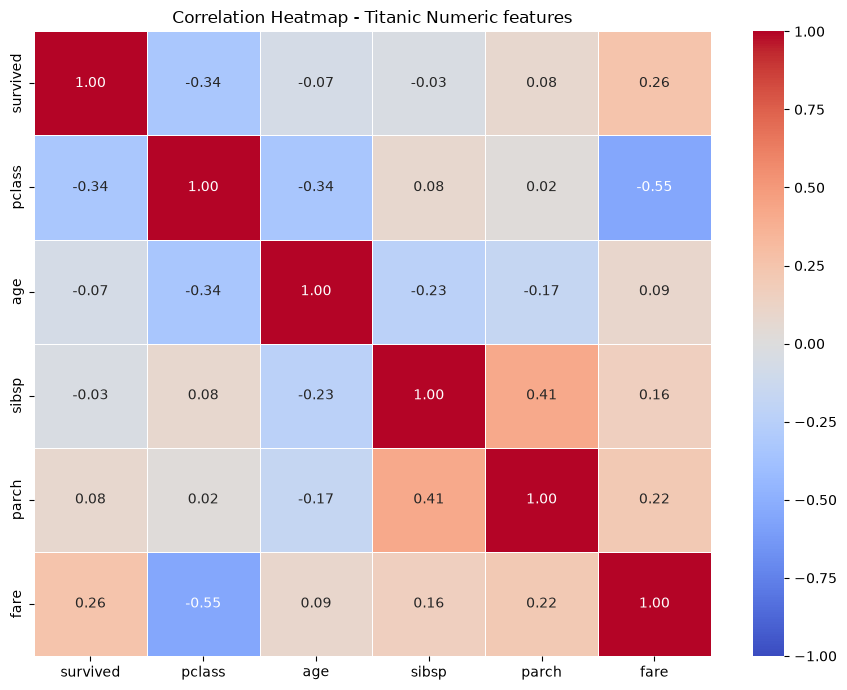

In [5]:
corr_columns = ["survived","pclass","age","sibsp","parch","fare"]

corr_matrix = df[corr_columns].corr()

print(f"Correlation Matrix:")
print(corr_matrix.round(4))

#Heatmap
plt.figure(figsize=(9,7))

sns.heatmap(corr_matrix,annot=True,cmap="coolwarm",fmt=".2f",linewidths=0.5,vmin=-1,vmax=1)

plt.title("Correlation Heatmap - Titanic Numeric features")
plt.tight_layout()
plt.show()

In [6]:
import numpy as np

upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape),k=1).astype(bool))

#Convert matrix into feature-pair records

correlation_pairs = (upper_triangle.stack().reset_index())

correlation_pairs.columns = ["Feature 1",  "Feature 2", "Correlation"]

#Rank by absolute correlation

correlation_pairs["Absolute Correlation"] = (correlation_pairs["Correlation"].abs())

top_two = correlation_pairs.sort_values(
    by="Absolute Correlation",
    ascending=False
).head(2)


print(f"\nTwo Strongest Correlations:")
print(top_two.to_string(index=False))


Two Strongest Correlations:
Feature 1 Feature 2  Correlation  Absolute Correlation
   pclass      fare    -0.548193              0.548193
    sibsp     parch     0.414542              0.414542


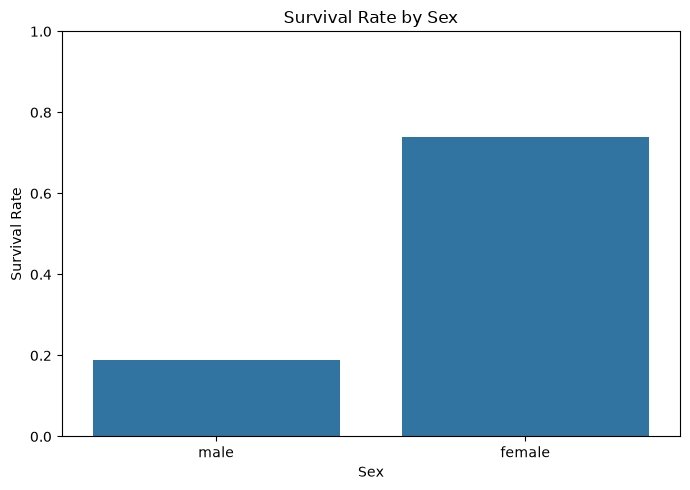

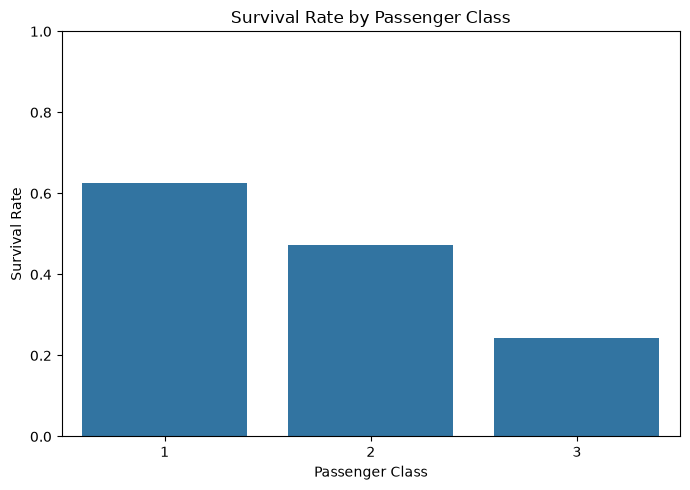

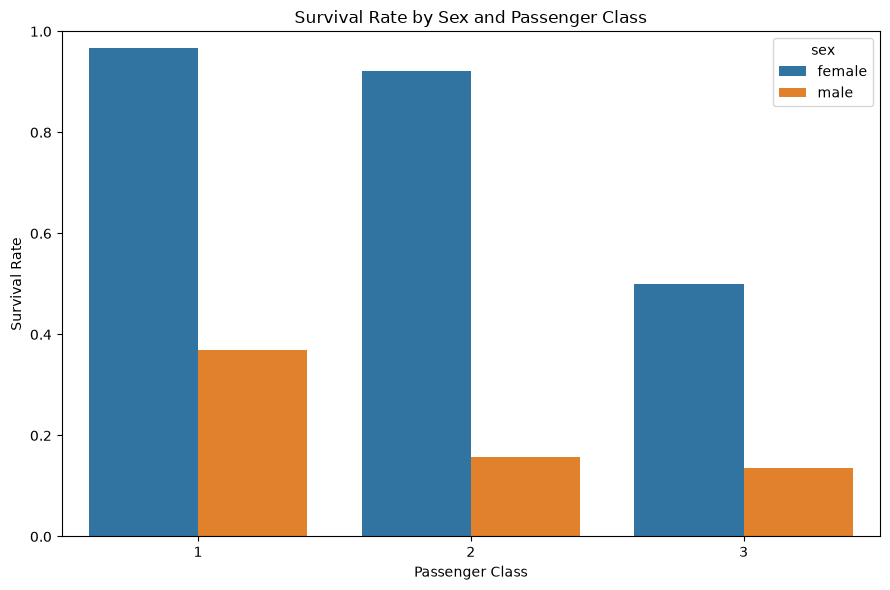

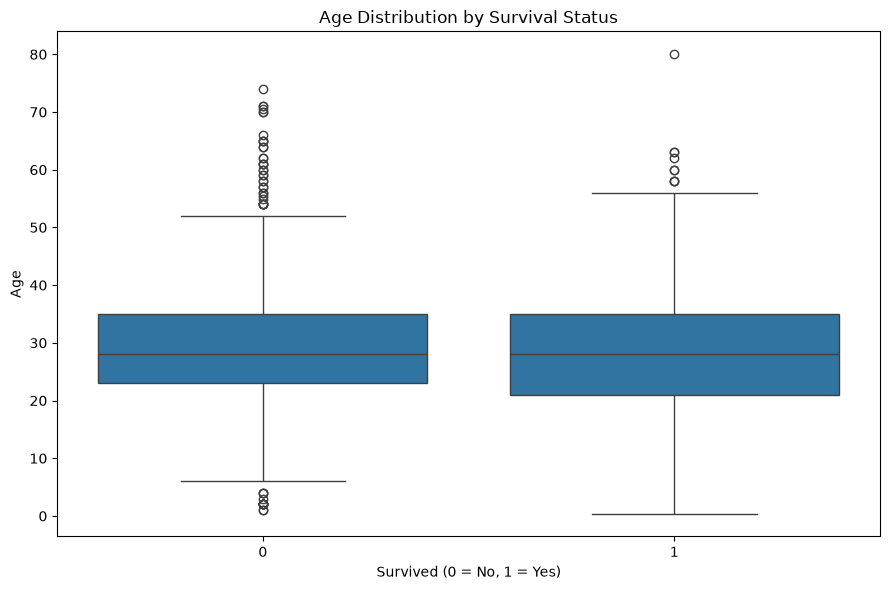

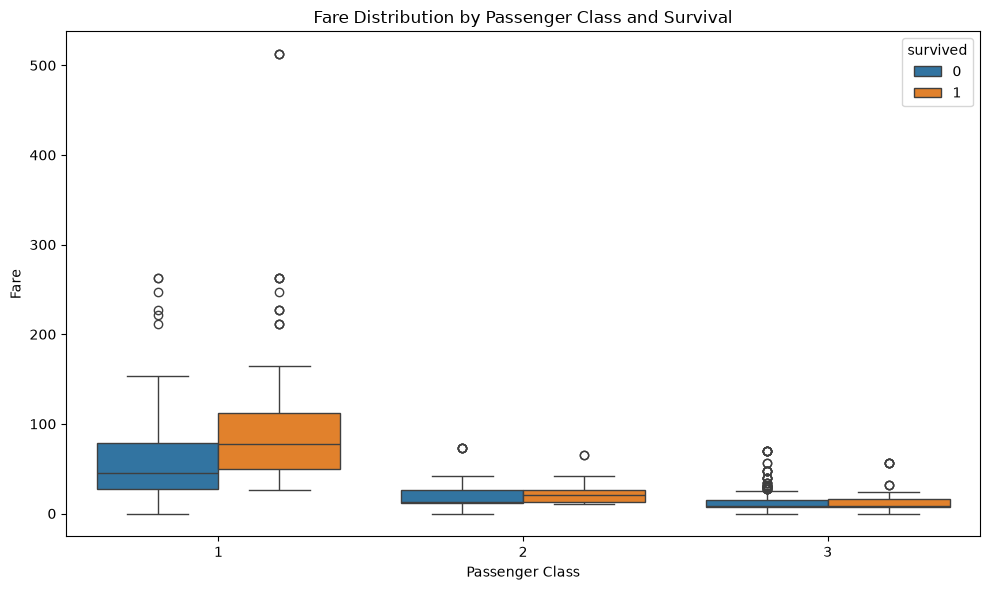

In [7]:
#Barplot Survival rate by sex

plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="sex",
    y="survived",
    estimator="mean",
    errorbar=None
)

plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

# Female passengers had a substantially higher survival rate than male passengers. This indicates that sex was an important factor associated with survival on the Titanic.
# #However, sex alone does not explain differences in passenger class or other characteristics.


#Survival rate by passenger class

plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="pclass",
    y="survived",
    estimator="mean",
    errorbar=None
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

#First-class passengers had the highest survival rate, followed by second-class and third-class passengers.
#This pattern suggests that passenger class was strongly associated with survival outcomes.
#Class may reflect differences in access to lifeboats, accommodation locations, and other conditions during the evaluation.

#Survival rate by sex and passenger class

plt.figure(figsize=(9, 6))

sns.barplot(
    data=df,
    x="pclass",
    y="survived",
    hue="sex",
    estimator="mean",
    errorbar=None
)

plt.title("Survival Rate by Sex and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

#Combining sex and passenger class reveals differences that are hidden when looking at either variable alone.
#Female passengers generally had higher survival rates within each class, while third-class passengers generally experienced lower survival rates.
#This chart supports the idea that survival was associated with an interaction between sex and socioeconomic position.

#Age distribution by survival status

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="survived",
    y="age"
)

plt.title("Age Distribution by Survival Status")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")

plt.tight_layout()
plt.show()

#The box plot compares the age distributions of survivors and non-survivors.
#Differences in median age and spread can indicate whether age was associated with survival.
#Younger passengers may have benefited from evacuation priorities, although age alone cannot establish the cause of survival.

#Fare and survival by passenger class

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="pclass",
    y="fare",
    hue="survived"
)

plt.title("Fare Distribution by Passenger Class and Survival")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")

plt.tight_layout()
plt.show()

#Fare distributions differ across passenger classes, reflecting the relationship between fare and socioeconomic position.
#Within each class, comparing survivors and non-survivors shows whether fare variation is associated with survival.
#This helps contextualize the correlation between fare, pclass, and survived without assuming that fare alone caused the outcome.

In [8]:
from sklearn.preprocessing import StandardScaler

columns_to_scale = ['age','fare']

#Before Standardization

print(f"Before Standardization")
print(df[columns_to_scale].agg(['mean','std']).T.round(4))

#Apply Z-score Standardization

scaler = StandardScaler()

#Creating a seperate Datafram for EDA

df_eda_scaled = df.copy()

#Fit and transform on the full cleaned Dataframe

df_eda_scaled[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

#After Standardization

print("\nAfter Standardization:")
print(df_eda_scaled[columns_to_scale].agg(['mean','std']).T.round(4))

#Verify Mean and Standard Deviation

print("\nSanity Check:")

for column in columns_to_scale:

    mean_after= df_eda_scaled[column].mean()
    std_after = df_eda_scaled[column].std(ddof=0)

    print(f"\nColumn: {column}")
    print(f"Mean after scaling: {mean_after:.6f}")
    print(f"Standard Deviation after scaling: {std_after:.6f}")



Before Standardization
         mean      std
age   29.3152  12.9849
fare  32.0967  49.6975

After Standardization:
      mean     std
age    0.0  1.0006
fare   0.0  1.0006

Sanity Check:

Column: age
Mean after scaling: 0.000000
Standard Deviation after scaling: 1.000000

Column: fare
Mean after scaling: 0.000000
Standard Deviation after scaling: 1.000000


TITANIC MODELING - TASKS 7 TO 15


TASK 7 - TRAIN / TEST SPLIT
----------------------------------------------------------------------
Training data shape: (711, 13)
Testing data shape : (178, 13)

Training class distribution:
survived
0    61.74
1    38.26
Name: proportion, dtype: float64

Testing class distribution:
survived
0    61.8
1    38.2
Name: proportion, dtype: float64

Why stratification matters:
Titanic has an unequal number of survivors and non-survivors.
Stratification preserves approximately the same class proportion
in both training and testing datasets.


TASK 8 - PREPROCESSING
----------------------------------------------------------------------
Numeric features: ['age', 'sibsp', 'parch', 'fare', 'pclass']
Categorical features: ['sex', 'embarked']

Preprocessing choice:
Numeric missing values -> median
Categorical missing values -> most frequent
Categorical variables -> One-Hot Encoding
Numeric variables -> StandardScaler
All preprocessing is fitted only on training d

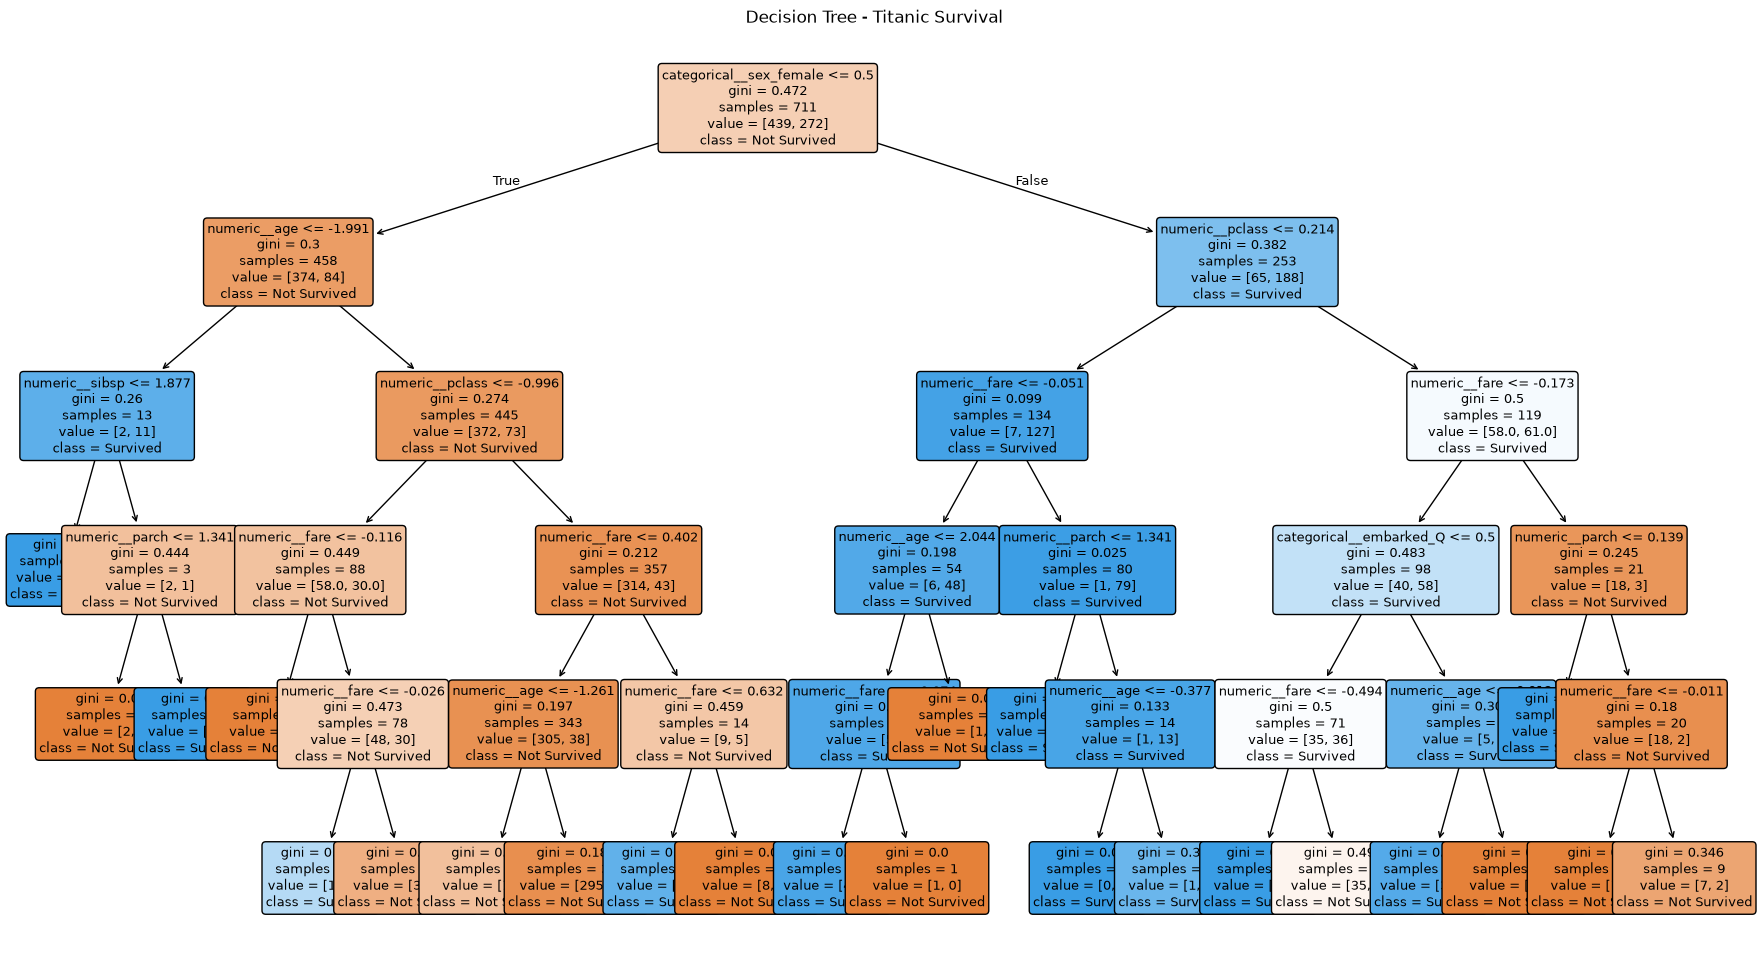



TASK 10 - MODEL EVALUATION
----------------------------------------------------------------------

Logistic Regression

Confusion Matrix:
[[97 13]
 [21 47]]

Accuracy : 0.809
Precision: 0.7833
Recall   : 0.6912
F1 Score : 0.7344
AUC      : 0.861

Decision Tree

Confusion Matrix:
[[97 13]
 [30 38]]

Accuracy : 0.7584
Precision: 0.7451
Recall   : 0.5588
F1 Score : 0.6387
AUC      : 0.8297

Random Forest

Confusion Matrix:
[[94 16]
 [22 46]]

Accuracy : 0.7865
Precision: 0.7419
Recall   : 0.6765
F1 Score : 0.7077
AUC      : 0.8151


CLASSIFICATION COMPARISON
----------------------------------------------------------------------
              Model  Accuracy  Precision  Recall     F1    AUC
Logistic Regression    0.8090     0.7833  0.6912 0.7344 0.8610
      Decision Tree    0.7584     0.7451  0.5588 0.6387 0.8297
      Random Forest    0.7865     0.7419  0.6765 0.7077 0.8151


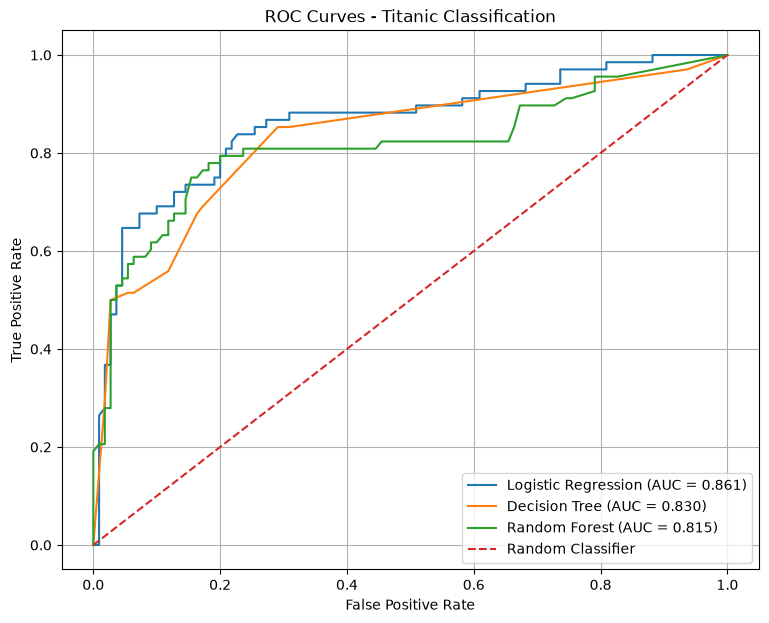



TASK 11 - CLASS IMBALANCE
----------------------------------------------------------------------

Class counts:
survived
Not Survived    549
Survived        340
Name: count, dtype: int64

Class percentages:
survived
Not Survived    61.75
Survived        38.25
Name: proportion, dtype: float64


IMBALANCE STRATEGY COMPARISON
----------------------------------------------------------------------
               Strategy  Precision  Recall     F1
               Baseline     0.7833  0.6912 0.7344
Class Weight = Balanced     0.7183  0.7500 0.7338
                  SMOTE     0.7353  0.7353 0.7353

Strategy with highest F1: SMOTE

Interpretation:
The baseline provides the reference performance.
Class weighting gives additional importance to the minority class.
SMOTE creates synthetic minority-class samples only in the training data.
The strategy with the strongest F1 provides the best balance between
precision and recall for this comparison.


TASK 12 - RANDOM FOREST GRID SEARCH
-------------

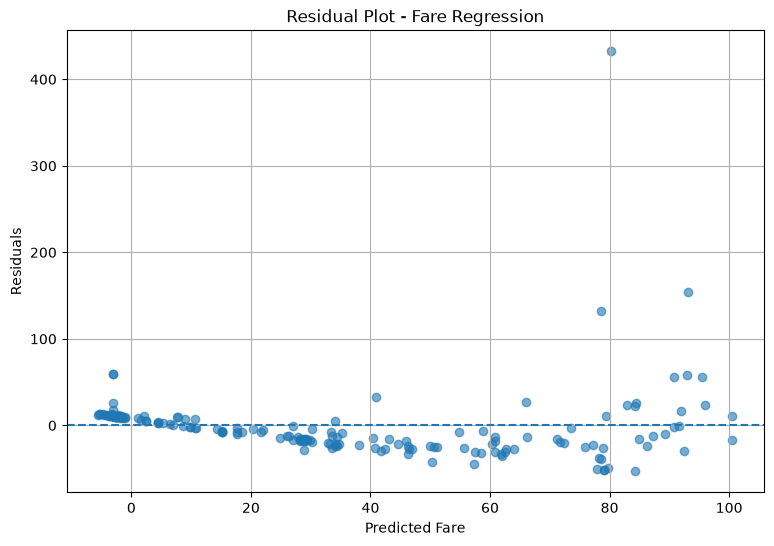


Residual interpretation:
If residuals are randomly distributed around zero with a
roughly constant spread, there is no strong visual evidence
of heteroscedasticity.
A funnel-shaped or systematically changing spread suggests
heteroscedasticity.


TASK 14 - FINAL MODEL COMPARISON
----------------------------------------------------------------------

CLASSIFICATION METRICS
----------------------------------------------------------------------
              Model  Accuracy  Precision  Recall     F1    AUC
Logistic Regression    0.8090     0.7833  0.6912 0.7344 0.8610
      Decision Tree    0.7584     0.7451  0.5588 0.6387 0.8297
      Random Forest    0.7865     0.7419  0.6765 0.7077 0.8151

REGRESSION METRICS
----------------------------------------------------------------------
              Regression Model     MAE    RMSE     R²  Adjusted R²
Multivariate Linear Regression 21.0986 41.7021 0.3482       0.3091


FINAL CLASSIFIER RECOMMENDATION
-------------------------------------------

In [9]:
# ============================================================
# TITANIC DATASET - TASKS 7 TO 15
# Classification + Imbalance Handling + Hyperparameter Tuning
# + Regression + Complete Pipeline Saving
# ============================================================


# ============================================================
# 0. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression, LinearRegression

from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE


# ============================================================
# IMPORTANT:
# df should already be your cleaned Titanic DataFrame
#
# If df is not available, uncomment these lines:
#
# import seaborn as sns
# df = sns.load_dataset("titanic")
#
# Task 2 cleaning should already have been completed.
# ============================================================


print("=" * 70)
print("TITANIC MODELING - TASKS 7 TO 15")
print("=" * 70)


# ============================================================
# TASK 7
# TRAIN / TEST SPLIT
# ============================================================

print("\n\nTASK 7 - TRAIN / TEST SPLIT")
print("-" * 70)

# Target
y = df["survived"]

# Features
X = df.drop(columns=["survived"])


# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("Training data shape:", X_train.shape)
print("Testing data shape :", X_test.shape)


print("\nTraining class distribution:")
print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)


print("\nTesting class distribution:")
print(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
)


print(
    "\nWhy stratification matters:"
    "\nTitanic has an unequal number of survivors and non-survivors."
    "\nStratification preserves approximately the same class proportion"
    "\nin both training and testing datasets."
)


# ============================================================
# TASK 8
# PREPROCESSING
# ============================================================

print("\n\nTASK 8 - PREPROCESSING")
print("-" * 70)


# Numeric columns
numeric_features = [
    "age",
    "sibsp",
    "parch",
    "fare",
    "pclass"
]


# Categorical columns
categorical_features = [
    "sex",
    "embarked"
]


# Numeric preprocessing:
# 1. Median imputation
# 2. StandardScaler
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])


# Categorical preprocessing:
# 1. Most frequent imputation
# 2. One-hot encoding
categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(handle_unknown="ignore")
    )
])


# Combine both
preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])


print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

print(
    "\nPreprocessing choice:"
    "\nNumeric missing values -> median"
    "\nCategorical missing values -> most frequent"
    "\nCategorical variables -> One-Hot Encoding"
    "\nNumeric variables -> StandardScaler"
    "\nAll preprocessing is fitted only on training data."
)


# ============================================================
# TASK 9
# TRAIN THREE CLASSIFIERS
# ============================================================

print("\n\nTASK 9 - TRAIN THREE CLASSIFIERS")
print("-" * 70)


# ------------------------------------------------------------
# Logistic Regression
# ------------------------------------------------------------

logistic_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])


# ------------------------------------------------------------
# Decision Tree
# ------------------------------------------------------------

decision_tree_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        DecisionTreeClassifier(
            max_depth=5,
            random_state=42
        )
    )
])


# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------

random_forest_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        )
    )
])


# ------------------------------------------------------------
# Train models
# ------------------------------------------------------------

logistic_model.fit(
    X_train,
    y_train
)

decision_tree_model.fit(
    X_train,
    y_train
)

random_forest_model.fit(
    X_train,
    y_train
)


print("Logistic Regression trained.")
print("Decision Tree trained.")
print("Random Forest trained.")


# ============================================================
# DECISION TREE VISUALIZATION
# ============================================================

print("\nRendering Decision Tree...")


# Get fitted preprocessing component
fitted_preprocessor = (
    decision_tree_model
    .named_steps["preprocessor"]
)


# Get transformed feature names
feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)


# Get fitted tree
tree_model = (
    decision_tree_model
    .named_steps["classifier"]
)


plt.figure(figsize=(22, 12))


plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=[
        "Not Survived",
        "Survived"
    ],
    filled=True,
    rounded=True,
    fontsize=9
)


plt.title(
    "Decision Tree - Titanic Survival"
)

plt.show()


# ============================================================
# TASK 10
# EVALUATE THREE CLASSIFIERS
# ============================================================

print("\n\nTASK 10 - MODEL EVALUATION")
print("-" * 70)


models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model
}


classification_results = []


for name, model in models.items():

    # Predictions
    y_pred = model.predict(X_test)

    # Probability of survival
    y_probability = model.predict_proba(
        X_test
    )[:, 1]


    # Metrics
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    auc = roc_auc_score(
        y_test,
        y_probability
    )


    # Store results
    classification_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc
    })


    # Confusion matrix
    cm = confusion_matrix(
        y_test,
        y_pred
    )


    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)

    print("\nConfusion Matrix:")
    print(cm)

    print("\nAccuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("AUC      :", round(auc, 4))


# Convert results into DataFrame
classification_comparison = pd.DataFrame(
    classification_results
)


print("\n\nCLASSIFICATION COMPARISON")
print("-" * 70)

print(
    classification_comparison
    .round(4)
    .to_string(index=False)
)


# ============================================================
# ROC CURVES
# ============================================================

plt.figure(figsize=(9, 7))


for name, model in models.items():

    y_probability = model.predict_proba(
        X_test
    )[:, 1]


    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_probability
    )


    auc = roc_auc_score(
        y_test,
        y_probability
    )


    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.3f})"
    )


# Random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)


plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curves - Titanic Classification"
)

plt.legend()
plt.grid()

plt.show()


# ============================================================
# TASK 11
# CLASS IMBALANCE
# ============================================================

print("\n\nTASK 11 - CLASS IMBALANCE")
print("-" * 70)


# Class counts
class_counts = (
    y.value_counts()
    .rename({
        0: "Not Survived",
        1: "Survived"
    })
)


# Class percentages
class_percentages = (
    y.value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename({
        0: "Not Survived",
        1: "Survived"
    })
)


print("\nClass counts:")
print(class_counts)


print("\nClass percentages:")
print(class_percentages)


# ------------------------------------------------------------
# A. BASELINE
# ------------------------------------------------------------

baseline_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000
        )
    )
])


baseline_model.fit(
    X_train,
    y_train
)


baseline_pred = baseline_model.predict(
    X_test
)


baseline_precision = precision_score(
    y_test,
    baseline_pred
)

baseline_recall = recall_score(
    y_test,
    baseline_pred
)

baseline_f1 = f1_score(
    y_test,
    baseline_pred
)


# ------------------------------------------------------------
# B. CLASS WEIGHT = BALANCED
# ------------------------------------------------------------

balanced_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        )
    )
])


balanced_model.fit(
    X_train,
    y_train
)


balanced_pred = balanced_model.predict(
    X_test
)


balanced_precision = precision_score(
    y_test,
    balanced_pred
)

balanced_recall = recall_score(
    y_test,
    balanced_pred
)

balanced_f1 = f1_score(
    y_test,
    balanced_pred
)


# ------------------------------------------------------------
# C. SMOTE
# ------------------------------------------------------------

smote_model = ImbPipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "smote",
        SMOTE(
            random_state=42
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000
        )
    )
])


smote_model.fit(
    X_train,
    y_train
)


smote_pred = smote_model.predict(
    X_test
)


smote_precision = precision_score(
    y_test,
    smote_pred
)

smote_recall = recall_score(
    y_test,
    smote_pred
)

smote_f1 = f1_score(
    y_test,
    smote_pred
)


# ------------------------------------------------------------
# Compare imbalance strategies
# ------------------------------------------------------------

imbalance_results = pd.DataFrame({
    "Strategy": [
        "Baseline",
        "Class Weight = Balanced",
        "SMOTE"
    ],
    "Precision": [
        baseline_precision,
        balanced_precision,
        smote_precision
    ],
    "Recall": [
        baseline_recall,
        balanced_recall,
        smote_recall
    ],
    "F1": [
        baseline_f1,
        balanced_f1,
        smote_f1
    ]
})


print("\n\nIMBALANCE STRATEGY COMPARISON")
print("-" * 70)

print(
    imbalance_results
    .round(4)
    .to_string(index=False)
)


# Find highest F1
best_imbalance_strategy = (
    imbalance_results
    .loc[
        imbalance_results["F1"].idxmax(),
        "Strategy"
    ]
)


print(
    "\nStrategy with highest F1:",
    best_imbalance_strategy
)


print(
    "\nInterpretation:"
    "\nThe baseline provides the reference performance."
    "\nClass weighting gives additional importance to the minority class."
    "\nSMOTE creates synthetic minority-class samples only in the training data."
    "\nThe strategy with the strongest F1 provides the best balance between"
    "\nprecision and recall for this comparison."
)


# ============================================================
# TASK 12
# RANDOM FOREST HYPERPARAMETER TUNING
# ============================================================

print("\n\nTASK 12 - RANDOM FOREST GRID SEARCH")
print("-" * 70)


# IMPORTANT:
# oob_score=True is specified here.
rf_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        RandomForestClassifier(
            random_state=42,
            oob_score=True
        )
    )
])


# Hyperparameter grid
param_grid = {
    "classifier__n_estimators": [
        100,
        200
    ],

    "classifier__max_depth": [
        None,
        5,
        10
    ],

    "classifier__max_features": [
        "sqrt",
        "log2"
    ]
}


grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)


grid_search.fit(
    X_train,
    y_train
)


print("\nBest Parameters:")
print(grid_search.best_params_)


print("\nBest Cross-Validation F1:")
print(
    round(
        grid_search.best_score_,
        4
    )
)


# Get best complete pipeline
best_rf_pipeline = grid_search.best_estimator_


# Get Random Forest from pipeline
best_rf = (
    best_rf_pipeline
    .named_steps["classifier"]
)


print("\nOOB Score:")
print(
    round(
        best_rf.oob_score_,
        4
    )
)


# ============================================================
# Evaluate tuned Random Forest
# ============================================================

tuned_rf_pred = best_rf_pipeline.predict(
    X_test
)

tuned_rf_probability = (
    best_rf_pipeline
    .predict_proba(X_test)[:, 1]
)


tuned_rf_accuracy = accuracy_score(
    y_test,
    tuned_rf_pred
)

tuned_rf_precision = precision_score(
    y_test,
    tuned_rf_pred
)

tuned_rf_recall = recall_score(
    y_test,
    tuned_rf_pred
)

tuned_rf_f1 = f1_score(
    y_test,
    tuned_rf_pred
)

tuned_rf_auc = roc_auc_score(
    y_test,
    tuned_rf_probability
)


print("\nTuned Random Forest Test Performance:")
print("Accuracy :", round(tuned_rf_accuracy, 4))
print("Precision:", round(tuned_rf_precision, 4))
print("Recall   :", round(tuned_rf_recall, 4))
print("F1       :", round(tuned_rf_f1, 4))
print("AUC      :", round(tuned_rf_auc, 4))


# ============================================================
# TASK 13
# REGRESSION - PREDICT FARE
# ============================================================

print("\n\nTASK 13 - MULTIVARIATE LINEAR REGRESSION")
print("-" * 70)


# Features used to predict fare
regression_features = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "sex",
    "embarked"
]


X_reg = df[
    regression_features
]

y_reg = df[
    "fare"
]


# Split regression data
X_reg_train, X_reg_test, y_reg_train, y_reg_test = (
    train_test_split(
        X_reg,
        y_reg,
        test_size=0.20,
        random_state=42
    )
)


# Regression numeric features
regression_numeric_features = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch"
]


# Regression categorical features
regression_categorical_features = [
    "sex",
    "embarked"
]


# Regression numeric preprocessing
regression_numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "scaler",
        StandardScaler()
    )
])


# Regression categorical preprocessing
regression_categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])


# Regression preprocessor
regression_preprocessor = ColumnTransformer([
    (
        "numeric",
        regression_numeric_pipeline,
        regression_numeric_features
    ),
    (
        "categorical",
        regression_categorical_pipeline,
        regression_categorical_features
    )
])


# Complete regression pipeline
regression_model = Pipeline([
    (
        "preprocessor",
        regression_preprocessor
    ),
    (
        "regressor",
        LinearRegression()
    )
])


# Fit regression
regression_model.fit(
    X_reg_train,
    y_reg_train
)


# Predict
y_reg_pred = regression_model.predict(
    X_reg_test
)


# ------------------------------------------------------------
# Regression metrics
# ------------------------------------------------------------

mae = mean_absolute_error(
    y_reg_test,
    y_reg_pred
)


rmse = np.sqrt(
    mean_squared_error(
        y_reg_test,
        y_reg_pred
    )
)


r2 = r2_score(
    y_reg_test,
    y_reg_pred
)


# Number of observations
n = len(y_reg_test)


# Number of predictors after encoding
p = (
    regression_model
    .named_steps["preprocessor"]
    .transform(X_reg_test)
    .shape[1]
)


# Adjusted R²
adjusted_r2 = 1 - (
    (1 - r2)
    * (n - 1)
    / (n - p - 1)
)


print("\nRegression Performance:")
print("MAE        :", round(mae, 4))
print("RMSE       :", round(rmse, 4))
print("R²         :", round(r2, 4))
print("Adjusted R²:", round(adjusted_r2, 4))


# ============================================================
# RESIDUAL PLOT
# ============================================================

residuals = (
    y_reg_test
    - y_reg_pred
)


plt.figure(figsize=(9, 6))


plt.scatter(
    y_reg_pred,
    residuals,
    alpha=0.6
)


plt.axhline(
    y=0,
    linestyle="--"
)


plt.xlabel(
    "Predicted Fare"
)

plt.ylabel(
    "Residuals"
)

plt.title(
    "Residual Plot - Fare Regression"
)

plt.grid()

plt.show()


print(
    "\nResidual interpretation:"
    "\nIf residuals are randomly distributed around zero with a"
    "\nroughly constant spread, there is no strong visual evidence"
    "\nof heteroscedasticity."
    "\nA funnel-shaped or systematically changing spread suggests"
    "\nheteroscedasticity."
)


# ============================================================
# TASK 14
# FINAL MODEL COMPARISON TABLE
# ============================================================

print("\n\nTASK 14 - FINAL MODEL COMPARISON")
print("-" * 70)


# ------------------------------------------------------------
# Classification metrics
# ------------------------------------------------------------

classification_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        classification_results[0]["Accuracy"],
        classification_results[1]["Accuracy"],
        classification_results[2]["Accuracy"]
    ],

    "Precision": [
        classification_results[0]["Precision"],
        classification_results[1]["Precision"],
        classification_results[2]["Precision"]
    ],

    "Recall": [
        classification_results[0]["Recall"],
        classification_results[1]["Recall"],
        classification_results[2]["Recall"]
    ],

    "F1": [
        classification_results[0]["F1"],
        classification_results[1]["F1"],
        classification_results[2]["F1"]
    ],

    "AUC": [
        classification_results[0]["AUC"],
        classification_results[1]["AUC"],
        classification_results[2]["AUC"]
    ]
})


print("\nCLASSIFICATION METRICS")
print("-" * 70)

print(
    classification_comparison
    .round(4)
    .to_string(index=False)
)


# ------------------------------------------------------------
# Regression metrics
# ------------------------------------------------------------

regression_comparison = pd.DataFrame({
    "Regression Model": [
        "Multivariate Linear Regression"
    ],

    "MAE": [
        mae
    ],

    "RMSE": [
        rmse
    ],

    "R²": [
        r2
    ],

    "Adjusted R²": [
        adjusted_r2
    ]
})


print("\nREGRESSION METRICS")
print("-" * 70)

print(
    regression_comparison
    .round(4)
    .to_string(index=False)
)


# ------------------------------------------------------------
# Identify classifier with highest F1
# ------------------------------------------------------------

best_classifier_row = (
    classification_comparison
    .loc[
        classification_comparison["F1"].idxmax()
    ]
)


print("\n\nFINAL CLASSIFIER RECOMMENDATION")
print("-" * 70)


print(
    f"The {best_classifier_row['Model']} achieved "
    f"an accuracy of {best_classifier_row['Accuracy']:.4f}, "
    f"precision of {best_classifier_row['Precision']:.4f}, "
    f"recall of {best_classifier_row['Recall']:.4f}, "
    f"F1 score of {best_classifier_row['F1']:.4f}, "
    f"and AUC of {best_classifier_row['AUC']:.4f}."
)


print(
    f"Among the three classifiers, it has the highest observed "
    f"F1 score in this test-set comparison."
)


print(
    "The F1 score provides a balance between precision and recall, "
    "while AUC measures the model's ability to distinguish between "
    "the two survival classes across classification thresholds."
)


print(
    f"Based on these observed test-set metrics, "
    f"{best_classifier_row['Model']} would be selected for "
    f"this Titanic classification task."
)


# ============================================================
# TASK 15
# SAVE COMPLETE BEST PIPELINE
# ============================================================

print("\n\nTASK 15 - SAVE COMPLETE PIPELINE")
print("-" * 70)


# ------------------------------------------------------------
# Save the tuned Random Forest pipeline
# ------------------------------------------------------------

joblib.dump(
    best_rf_pipeline,
    "titanic_best_pipeline.joblib"
)


print(
    "Complete pipeline saved as:"
)

print(
    "titanic_best_pipeline.joblib"
)


# ============================================================
# RELOAD SAVED PIPELINE
# ============================================================

loaded_pipeline = joblib.load(
    "titanic_best_pipeline.joblib"
)


print(
    "\nSaved pipeline successfully reloaded."
)


# ============================================================
# TEST SAVED PIPELINE WITH RAW INPUT
# ============================================================

new_passenger = pd.DataFrame({
    "age": [30],
    "sibsp": [0],
    "parch": [0],
    "fare": [50],
    "pclass": [2],
    "sex": ["female"],
    "embarked": ["S"]
})


# Predict directly from raw input
saved_prediction = (
    loaded_pipeline
    .predict(new_passenger)
)


saved_probability = (
    loaded_pipeline
    .predict_proba(new_passenger)[:, 1]
)


print("\nRaw input:")
print(new_passenger)


print(
    "\nPrediction:",
    saved_prediction[0]
)


print(
    "Survival probability:",
    round(
        saved_probability[0],
        4
    )
)


# ============================================================
# FINAL CHECK
# ============================================================

print("\n" + "=" * 70)
print("ALL TASKS 7-15 COMPLETED")
print("=" * 70)

print("""
The saved pipeline contains:

Raw Data
    ↓
Missing Value Imputation
    ↓
One-Hot Encoding
    ↓
StandardScaler
    ↓
Tuned Random Forest
    ↓
Prediction

The preprocessing is therefore applied automatically when
new raw passenger data is supplied.
""")